In [24]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Load the dataset
churn_df = pd.read_csv('churn_df.csv')

# Display first few rows to understand the data
churn_df.head()

,Unnamed: 0,account_length,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge,customer_service_calls,churn
0,0,101,45.85,17.65,9.64,1.22,3,1
1,1,73,22.30,9.05,9.98,2.75,2,0
2,2,86,24.62,17.53,11.49,3.13,4,0
3,3,59,34.73,21.02,9.66,3.24,1,0
4,4,129,27.42,18.75,10.11,2.59,1,0


In [25]:
# Create feature array X with "account_length" and "customer_service_calls" columns
X = churn_df[["account_length", "customer_service_calls"]].values

# Create target array y with "churn" column
y = churn_df["churn"].values

# Instantiate KNeighborsClassifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=6)

# Fit the classifier to the data
knn.fit(X, y)

print(f"Feature array shape: {X.shape}")
print(f"Target array shape: {y.shape}")

Feature array shape: (3333, 2)
Target array shape: (3333,)


In [26]:
X_new = np.array([[30.0, 17.5],
[107.0, 24.1],
[213.0, 10.9]])

# Create y_pred by predicting target values for unseen features X_new
y_pred = knn.predict(X_new)

# Print the predicted labels
print("Predicted labels for X_new:")
print(y_pred)

Predicted labels for X_new:
[0 1 0]


In [27]:
from sklearn.model_selection import train_test_split

# Create feature array X with "account_length" and "customer_service_calls" columns
X = churn_df[["account_length", "customer_service_calls"]].values

# Create target array y with "churn" column
y = churn_df["churn"].values

# Split X and y into training and test sets, setting test_size equal to 20%, random_state to 42, and ensuring the target label proportions reflect that of the original dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set k = 5
k = 5

# Instantiate KNeighborsClassifier with 6 neighbors and fit it to the training data
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Compute and print the model's accuracy for the test data.
accuracy = knn.score(X_test, y_test)
print(f"Model accuracy for the test data: {accuracy}")

Model accuracy for the test data: 0.8365817091454273


Training Accuracies: {np.int64(1): 0.8563390847711928, np.int64(2): 0.8795948987246812, np.int64(3): 0.8780945236309077, np.int64(4): 0.8739684921230307, np.int64(5): 0.8758439609902475, np.int64(6): 0.8717179294823706, np.int64(7): 0.8702175543885972, np.int64(8): 0.8668417104276069, np.int64(9): 0.8660915228807202, np.int64(10): 0.8653413353338335, np.int64(11): 0.8660915228807202, np.int64(12): 0.8623405851462865}
Test Accuracies: {np.int64(1): 0.7586206896551724, np.int64(2): 0.8215892053973014, np.int64(3): 0.808095952023988, np.int64(4): 0.8350824587706147, np.int64(5): 0.8365817091454273, np.int64(6): 0.8425787106446777, np.int64(7): 0.8395802098950524, np.int64(8): 0.8350824587706147, np.int64(9): 0.8335832083958021, np.int64(10): 0.8365817091454273, np.int64(11): 0.8350824587706147, np.int64(12): 0.8350824587706147}


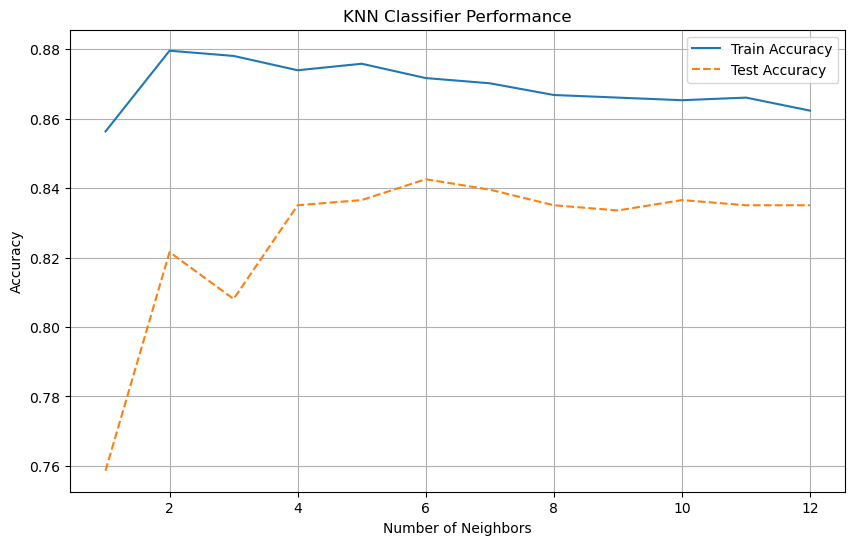

In [28]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Create an array of neighbor values from 1 to 12
neighbors = np.arange(1, 13)

# Initialize dictionaries to store accuracy scores
train_accuracies = {}
test_accuracies = {}

# Loop through each number of neighbors and fit the model
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    
    # Calculate accuracy scores for training and test sets
    train_accuracy = knn.score(X_train, y_train)
    test_accuracy = knn.score(X_test, y_test)
    
    # Store the accuracy scores in dictionaries
    train_accuracies[n] = train_accuracy
    test_accuracies[n] = test_accuracy

# Print the accuracy scores
print("Training Accuracies:", train_accuracies)
print("Test Accuracies:", test_accuracies)

# Plotting the accuracy scores
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracies.values(), label='Train Accuracy')
plt.plot(neighbors, test_accuracies.values(), label='Test Accuracy', linestyle='--')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('KNN Classifier Performance')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
diabetes_df = pd.read_csv('diabetes.csv', index_col = 0)
print(diabetes_df.shape)
diabetes_df = diabetes_df[diabetes_df['bmi'] != 0]
print(diabetes_df.shape)
diabetes_df = diabetes_df[diabetes_df['glucose'] != 0]
print(diabetes_df.shape)
diabetes_df.head()

(768, 7)
(757, 7)
(752, 7)


,pregnancies,glucose,triceps,insulin,bmi,age,diabetes
0,6,148,35,0,33.6,50,1
1,1,85,29,0,26.6,31,0
2,8,183,0,0,23.3,32,1
3,1,89,23,94,28.1,21,0
4,0,137,35,168,43.1,33,1


In [30]:
# Load the sales dataset
sales_df = pd.read_csv('sales_df.csv')

# Display first few rows to understand the data
sales_df.head()

,Unnamed: 0,tv,radio,social_media,sales
0,0,16000.0,6566.23,2907.98,54732.76
1,1,13000.0,9237.76,2409.57,46677.90
2,2,41000.0,15886.45,2913.41,150177.83
3,3,83000.0,30020.03,6922.30,298246.34
4,4,15000.0,8437.41,1406.00,56594.18


In [31]:
import numpy as np

# Create X from the "radio" column
X = sales_df["radio"].values

# Create y from the "sales" column
y = sales_df["sales"].values

# Reshape X into a two-dimensional NumPy array
X = X.reshape(-1, 1)

# Print the shape of X and y
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (4546, 1)
Shape of y: (4546,)


In [32]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression

# Instantiate a linear regression model
reg = LinearRegression()

# Fit the model to the data
reg.fit(X, y)

# Predict sales values using X, storing as predictions
predictions = reg.predict(X)

# Print five prediction values
print("First five predicted sales values:")
print(predictions[:5])

First five predicted sales values:
[ 95491.17119147 117829.51038393 173423.38071499 291603.11444202
 111137.28167129]


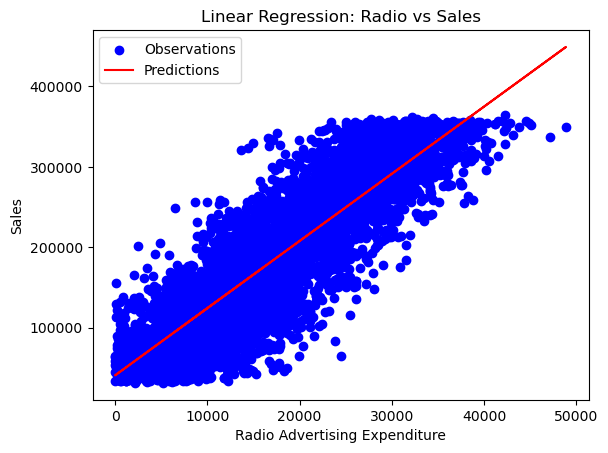

In [33]:
# Create scatter plot of actual sales vs radio (blue observations)
plt.scatter(X, y, color='blue', label='Observations')

# Draw red line plot of predictions vs radio
plt.plot(X, predictions, color='red', label='Predictions')

# Add labels and title
plt.xlabel('Radio Advertising Expenditure')
plt.ylabel('Sales')
plt.title('Linear Regression: Radio vs Sales')

# Add legend
plt.legend()

# Display the plot
plt.show()

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the sales dataset
sales_df = pd.read_csv('sales_df.csv')

# Display first few rows to understand the data
print(sales_df.head())

# Split the dataset into training and test sets, setting test_size equal to 20%, random_state to 42, and ensuring the target label proportions reflect that of the original dataset.
X_train, X_test, y_train, y_test = train_test_split(sales_df.drop('sales', axis=1), sales_df['sales'], test_size=0.2, random_state=42)

# Instantiate a linear regression model
reg = LinearRegression()

# Fit the model to the training data
reg.fit(X_train, y_train)

# Make predictions using the test features
y_pred = reg.predict(X_test)

# Print the first two values of y_pred and y_test
print("First two predicted sales values:")
print(y_pred[:2])
print("First two actual sales values:")
print(y_test[:2])

   Unnamed: 0       tv     radio  social_media      sales
0           0  16000.0   6566.23       2907.98   54732.76
1           1  13000.0   9237.76       2409.57   46677.90
2           2  41000.0  15886.45       2913.41  150177.83
3           3  83000.0  30020.03       6922.30  298246.34
4           4  15000.0   8437.41       1406.00   56594.18
First two predicted sales values:
[53211.24654996 71094.18581089]
First two actual sales values:
471     55261.28
3774    67574.90
Name: sales, dtype: float64


In [35]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Calculate the model's R-squared score
r_squared = reg.score(X_test, y_test)

# Calculate the model's root mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print(f"R-squared: {r_squared}")
print(f"Root Mean Squared Error: {rmse}")

R-squared: 0.9990108723060241
Root Mean Squared Error: 2884.261780626478


In [36]:
# Import KFold and cross_val_score
from sklearn.model_selection import KFold, cross_val_score

# Create X from "radio" and "social_media" columns
X = sales_df[["radio", "social_media"]].values

# Create y from the "sales" column
y = sales_df["sales"].values

# Instantiate a linear regression model
reg = LinearRegression()

# Create kf with 6 splits, shuffle=True, and random_state=5
kf = KFold(n_splits=6, shuffle=True, random_state=5)

# Perform 6-fold cross-validation
cv_scores = cross_val_score(reg, X, y, cv=kf)

# Print the cv_scores
print("Cross-validation scores for each fold:")
print(cv_scores)

# Calculate and print the mean of cv_scores
print(f"\nMean CV Score: {cv_scores.mean()}")

# Calculate and print the standard deviation of cv_scores
print(f"Standard Deviation of CV Scores: {cv_scores.std()}")

# Display the 95% confidence interval using np.quantile()
confidence_interval = np.quantile(cv_scores, [0.025, 0.975])
print(f"\n95% Confidence Interval: {confidence_interval}")

Cross-validation scores for each fold:
[0.74451678 0.77241887 0.76842114 0.7410406  0.75170022 0.74406484]

Mean CV Score: 0.7536937414361207
Standard Deviation of CV Scores: 0.012305389070474737

95% Confidence Interval: [0.74141863 0.77191916]
